Loaded: (3819, 28)


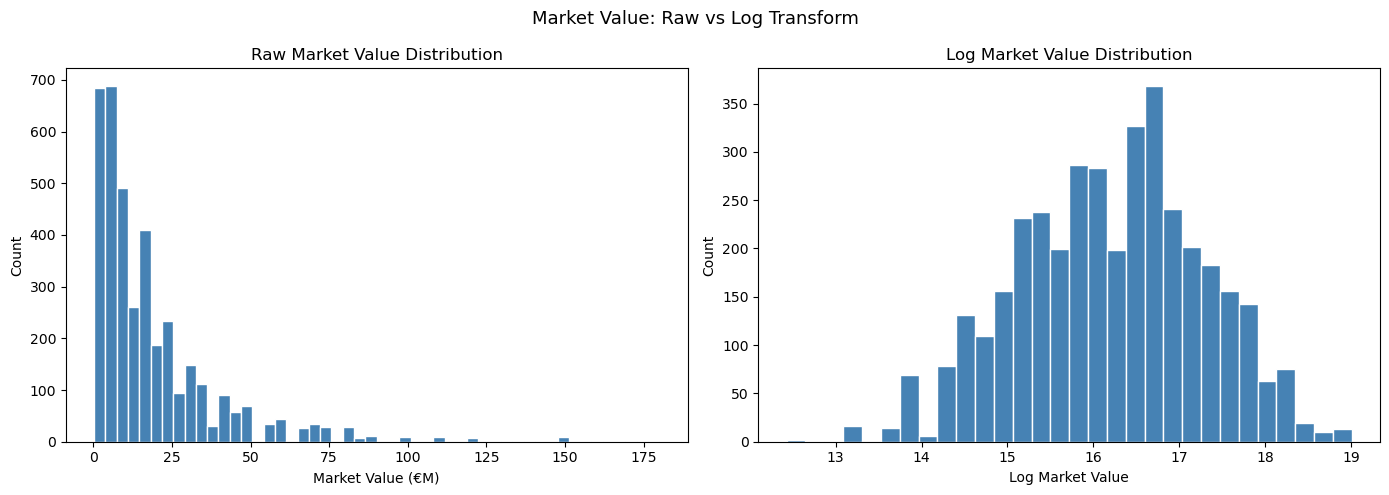

Saved: eda_market_value_distribution.png


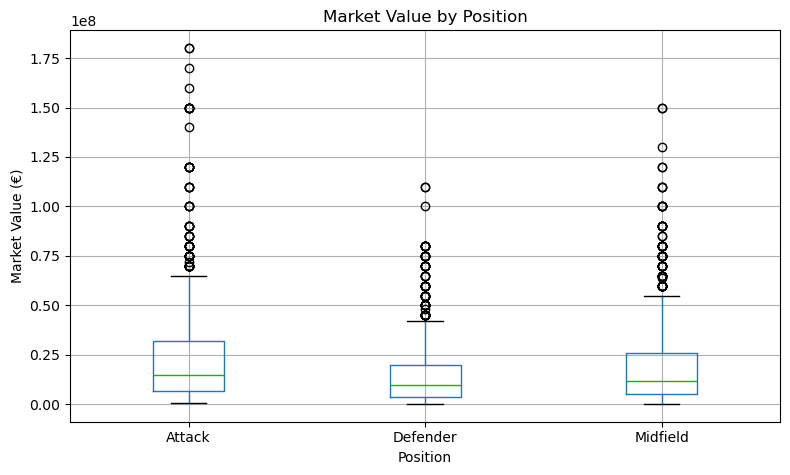

Saved: eda_value_by_position.png


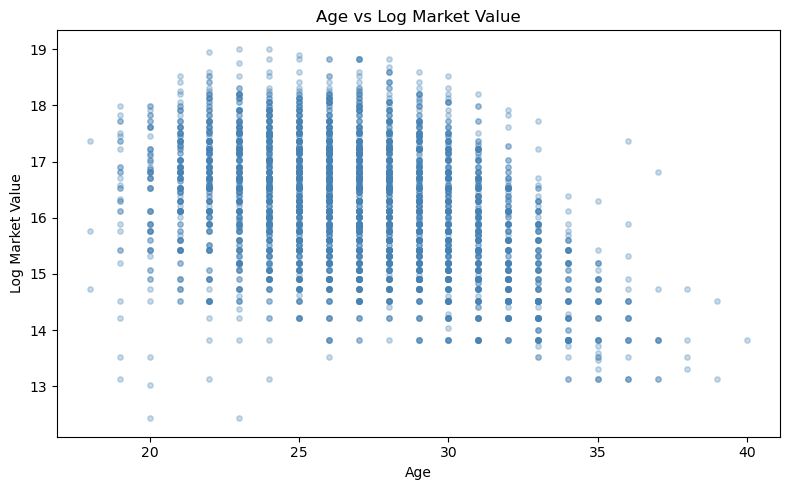

Saved: eda_age_vs_value.png


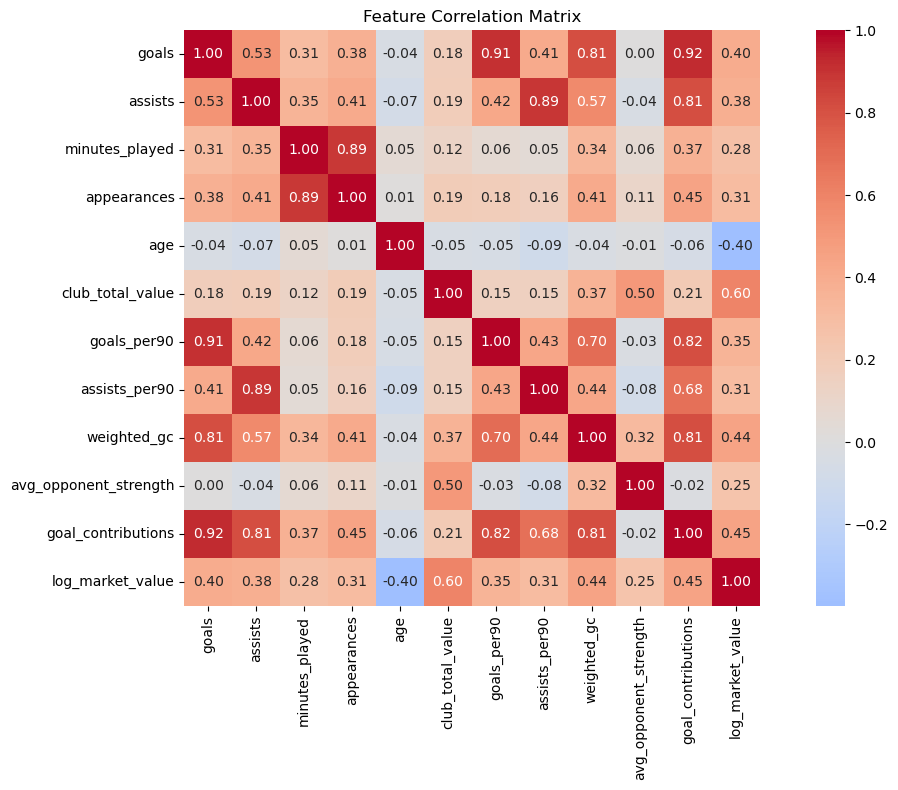

Saved: eda_correlation_matrix.png

── Correlations with log_market_value ──
club_total_value         0.600148
goal_contributions       0.447500
weighted_gc              0.444421
goals                    0.400380
assists                  0.383829
goals_per90              0.351867
assists_per90            0.311056
appearances              0.309954
minutes_played           0.275405
avg_opponent_strength    0.253009
age                     -0.397618
Name: log_market_value, dtype: float64


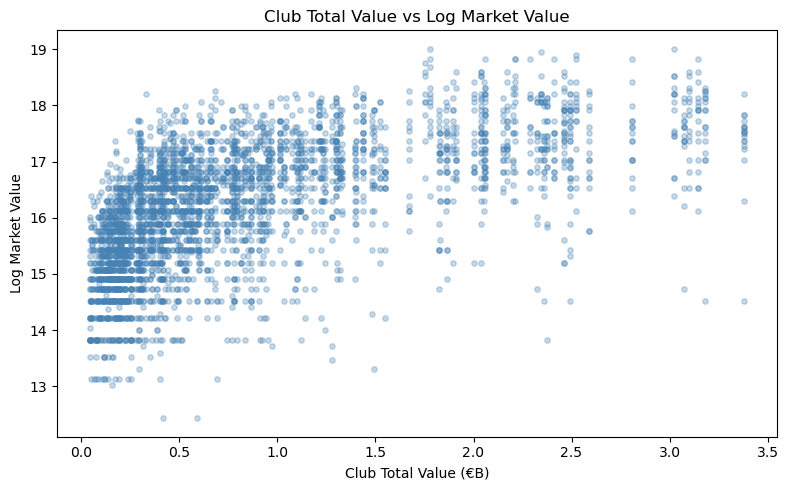

Saved: eda_club_value_vs_mv.png

── Dataset Summary ──
Total player-season observations: 3819
Seasons covered: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique players: 1176

── Market Value ──
Mean:   €18.6M
Median: €12.0M
Max:    €180.0M
Min:    €0.2M


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load engineered dataset
df = pd.read_csv('../thesis_dataset/engineered_dataset.csv')
print(f"Loaded: {df.shape}")

# 1. Market Value Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['market_value'] / 1e6, bins=50, color='steelblue', 
             edgecolor='white')
axes[0].set_title('Raw Market Value Distribution')
axes[0].set_xlabel('Market Value (€M)')
axes[0].set_ylabel('Count')

axes[1].hist(df['log_market_value'], bins=30, color='steelblue', 
             edgecolor='white')
axes[1].set_title('Log Market Value Distribution')
axes[1].set_xlabel('Log Market Value')
axes[1].set_ylabel('Count')

plt.suptitle('Market Value: Raw vs Log Transform', fontsize=13)
plt.tight_layout()
plt.savefig('../thesis_dataset/eda_market_value_distribution.png', dpi=150)
plt.show()
print("Saved: eda_market_value_distribution.png")

# ── 2. Market Value by Position ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='market_value', by='position', ax=ax)
ax.set_title('Market Value by Position')
ax.set_xlabel('Position')
ax.set_ylabel('Market Value (€)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../thesis_dataset/eda_value_by_position.png', dpi=150)
plt.show()
print("Saved: eda_value_by_position.png")

# 3. Age vs Log Market Value
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['age'], df['log_market_value'], 
           alpha=0.3, color='steelblue', s=15)
ax.set_title('Age vs Log Market Value')
ax.set_xlabel('Age')
ax.set_ylabel('Log Market Value')
plt.tight_layout()
plt.savefig('../thesis_dataset/eda_age_vs_value.png', dpi=150)
plt.show()
print("Saved: eda_age_vs_value.png")

# 4. Correlation Matrix
numeric_cols = [
    'goals', 'assists', 'minutes_played', 'appearances',
    'age', 'club_total_value', 'goals_per90', 'assists_per90',
    'weighted_gc', 'avg_opponent_strength',
    'goal_contributions', 'log_market_value'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../thesis_dataset/eda_correlation_matrix.png', dpi=150)
plt.show()
print("Saved: eda_correlation_matrix.png")

# 5. Key correlations with target
print("\n── Correlations with log_market_value ──")
print(
    corr_matrix['log_market_value']
    .drop('log_market_value')
    .sort_values(ascending=False)
)

# 6. Club value vs market value
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['club_total_value'] / 1e9, 
           df['log_market_value'],
           alpha=0.3, color='steelblue', s=15)
ax.set_title('Club Total Value vs Log Market Value')
ax.set_xlabel('Club Total Value (€B)')
ax.set_ylabel('Log Market Value')
plt.tight_layout()
plt.savefig('../thesis_dataset/eda_club_value_vs_mv.png', dpi=150)
plt.show()
print("Saved: eda_club_value_vs_mv.png")

# 7. Summary statistics
print("\n── Dataset Summary ──")
print(f"Total player-season observations: {len(df)}")
print(f"Seasons covered: {sorted(df['season'].unique())}")
print(f"Unique players: {df['player_id'].nunique()}")
print(f"\n── Market Value ──")
print(f"Mean:   €{df['market_value'].mean()/1e6:.1f}M")
print(f"Median: €{df['market_value'].median()/1e6:.1f}M")
print(f"Max:    €{df['market_value'].max()/1e6:.1f}M")
print(f"Min:    €{df['market_value'].min()/1e6:.1f}M")